# Adult Income: Exploratory Data Analysis
### Understanding the factors associated with earning above $50K

**Project type:** Exploratory Data Analysis (EDA)  
**Dataset:** Adult / Census Income dataset  
**Goal:** Explore demographic, educational and employment characteristics associated with income category.

> This notebook emphasizes **rates and proportions**, not just raw counts. This helps avoid misleading conclusions when category sizes differ substantially.


## Table of Contents
1. Project Objectives  
2. Import Libraries and Load Data  
3. Dataset Understanding  
4. Data Quality Assessment and Cleaning  
5. Feature Engineering  
6. Univariate Analysis  
7. Income-Focused Bivariate Analysis  
8. Multivariate Exploration  
9. Key Findings  
10. Recommendations and Next Steps


## 1. Project Objectives

This analysis seeks to answer:

- What does the population in the dataset look like?
- Which education levels and occupations have the strongest association with higher income?
- How do age and weekly work hours differ across income groups?
- How do workclass, marital status, sex, race and native country relate to income?
- Which numerical variables move together?
- What additional features could be useful in a future predictive model?

**Important:** This is observational EDA. Associations shown here should not be interpreted as proof that a characteristic *causes* higher or lower income.


## 2. Import Libraries and Load Data


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

# Keep adult.csv in the same folder as this notebook.
adult_df = pd.read_csv("C:/Users/MRS OLALERU/OneDrive/Documents/New folder/Datasets/Adult income/adult.csv")
adult_df.columns = adult_df.columns.str.strip()

# Remove accidental surrounding spaces in categorical values.
for col in adult_df.select_dtypes(include="object").columns:
    adult_df[col] = adult_df[col].str.strip()

adult_df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 3. Dataset Understanding


In [4]:
print(f"Rows: {adult_df.shape[0]:,}")
print(f"Columns: {adult_df.shape[1]}")
display(adult_df.head())
display(adult_df.sample(5, random_state=42))


Rows: 32,561
Columns: 15


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
14160,29,Private,280618,Some-college,10,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States,<=50K
27048,19,Private,439779,Some-college,10,Never-married,Sales,Own-child,White,Male,0,0,15,United-States,<=50K
28868,28,Private,204734,Some-college,10,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,40,United-States,<=50K
5667,35,Private,107991,11th,7,Never-married,Sales,Not-in-family,White,Male,0,0,45,United-States,<=50K
7827,20,Private,54152,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,30,?,<=50K


In [5]:
# Column names, data types and non-null counts
adult_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [6]:
# Numerical summary
adult_df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [7]:
# Categorical summary
adult_df.describe(include="object").T


,count,unique,top,freq
workclass,32561,9,Private,22696
education,32561,16,HS-grad,10501
marital.status,32561,7,Married-civ-spouse,14976
occupation,32561,15,Prof-specialty,4140
relationship,32561,6,Husband,13193
race,32561,5,White,27816
sex,32561,2,Male,21790
native.country,32561,42,United-States,29170
income,32561,2,<=50K,24720


### Initial observation
The dataset combines numerical attributes (such as age, education number, capital gain/loss and hours per week) with categorical attributes describing employment, education, family relationships and demographic characteristics.


## 4. Data Quality Assessment and Cleaning


In [8]:
quality_report = pd.DataFrame({
    "dtype": adult_df.dtypes.astype(str),
    "missing_null": adult_df.isna().sum(),
    "unique_values": adult_df.nunique()
})
quality_report


,dtype,missing_null,unique_values
age,int64,0,73
workclass,str,0,9
fnlwgt,int64,0,21648
education,str,0,16
education.num,int64,0,16
marital.status,str,0,7
occupation,str,0,15
relationship,str,0,6
race,str,0,5
sex,str,0,2


In [9]:
# '?' represents missing/unknown information in this dataset.
question_marks = (adult_df.astype(str) == "?").sum()
question_marks[question_marks > 0].sort_values(ascending=False)


occupation        1843
workclass         1836
native.country     583
dtype: int64

In [10]:
print("Duplicate rows:", adult_df.duplicated().sum())

adult_clean = (
    adult_df
    .replace("?", np.nan)
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Original rows : {len(adult_df):,}")
print(f"Clean rows    : {len(adult_clean):,}")
print(f"Rows retained : {len(adult_clean)/len(adult_df)*100:.2f}%")


Duplicate rows: 24
Original rows : 32,561
Clean rows    : 30,139
Rows retained : 92.56%


### Cleaning insight
After treating `?` as missing data, removing incomplete records and removing exact duplicate rows, the cleaned dataset retains approximately **92.6%** of the original observations. Keeping track of this retention rate is important because aggressive row removal can change the population represented by the analysis.


## 5. Feature Engineering


In [11]:
# Binary target for percentage/rate calculations.
adult_clean["high_income"] = (adult_clean["income"] == ">50K").astype(int)

# Interpretable age groups.
adult_clean["age_group"] = pd.cut(
    adult_clean["age"],
    bins=[16, 24, 34, 44, 54, 64, 100],
    labels=["17–24", "25–34", "35–44", "45–54", "55–64", "65+"]
)

# Work-hour bands.
adult_clean["work_hours_group"] = pd.cut(
    adult_clean["hours.per.week"],
    bins=[0, 29, 39, 40, 49, 200],
    labels=["<30", "30–39", "40", "41–49", "50+"]
)

adult_clean[["age", "age_group", "hours.per.week", "work_hours_group", "income"]].head()


,age,age_group,hours.per.week,work_hours_group,income
0,82,65+,18,<30,<=50K
1,54,45–54,40,40,<=50K
2,41,35–44,40,40,<=50K
3,34,25–34,45,41–49,<=50K
4,38,35–44,40,40,<=50K


## 6. Univariate Analysis


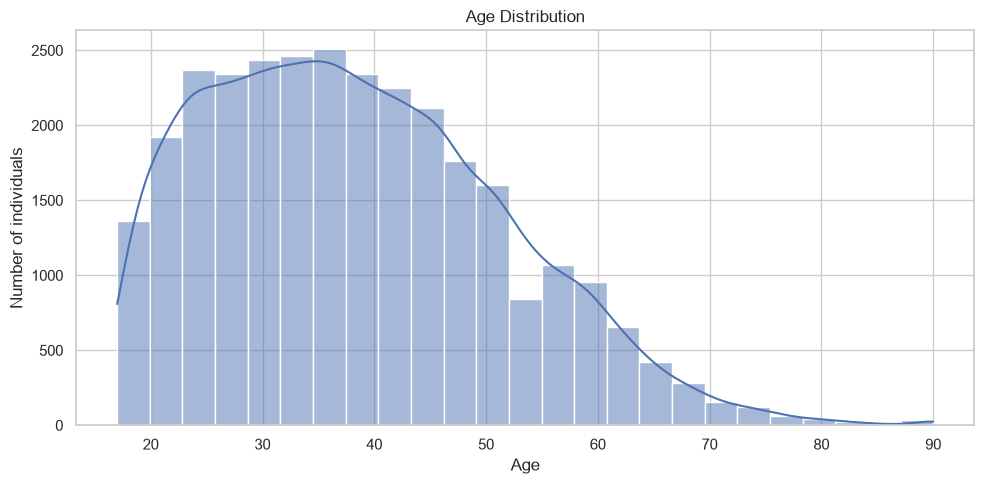

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=adult_clean, x="age", bins=25, kde=True, ax=ax)
ax.set(title="Age Distribution", xlabel="Age", ylabel="Number of individuals")
plt.tight_layout()
plt.show()


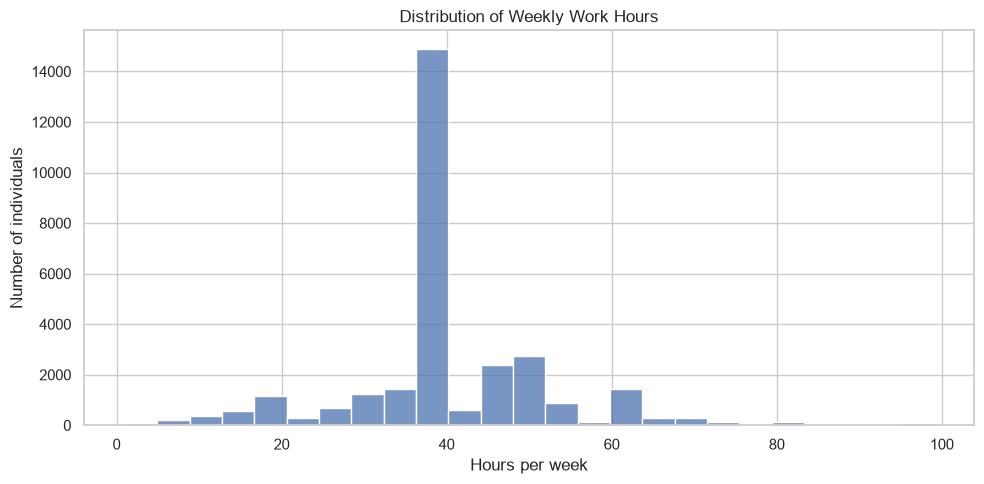

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=adult_clean, x="hours.per.week", bins=25, ax=ax)
ax.set(title="Distribution of Weekly Work Hours", xlabel="Hours per week", ylabel="Number of individuals")
plt.tight_layout()
plt.show()


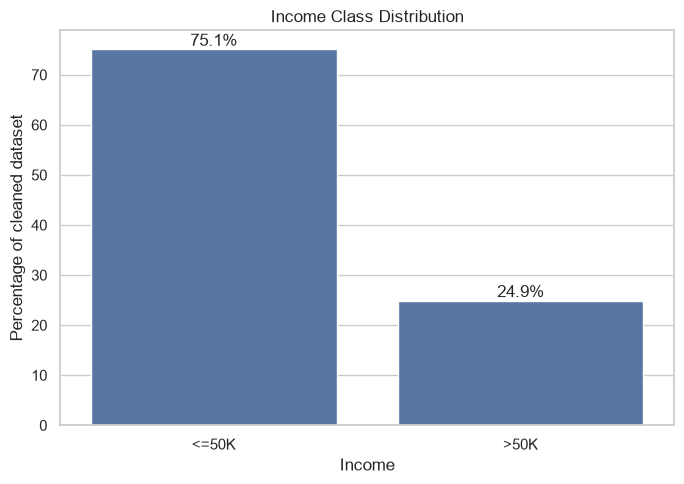

In [14]:
income_pct = adult_clean["income"].value_counts(normalize=True).mul(100)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=income_pct.index, y=income_pct.values, ax=ax)
ax.set(title="Income Class Distribution", xlabel="Income", ylabel="Percentage of cleaned dataset")
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.tight_layout()
plt.show()


### Income balance
About **24.9%** of cleaned observations belong to the higher-income (`>50K`) category. This imbalance is important: raw category counts can easily overstate the importance of the larger income group, so later comparisons use **within-group percentages/high-income rates** wherever possible.


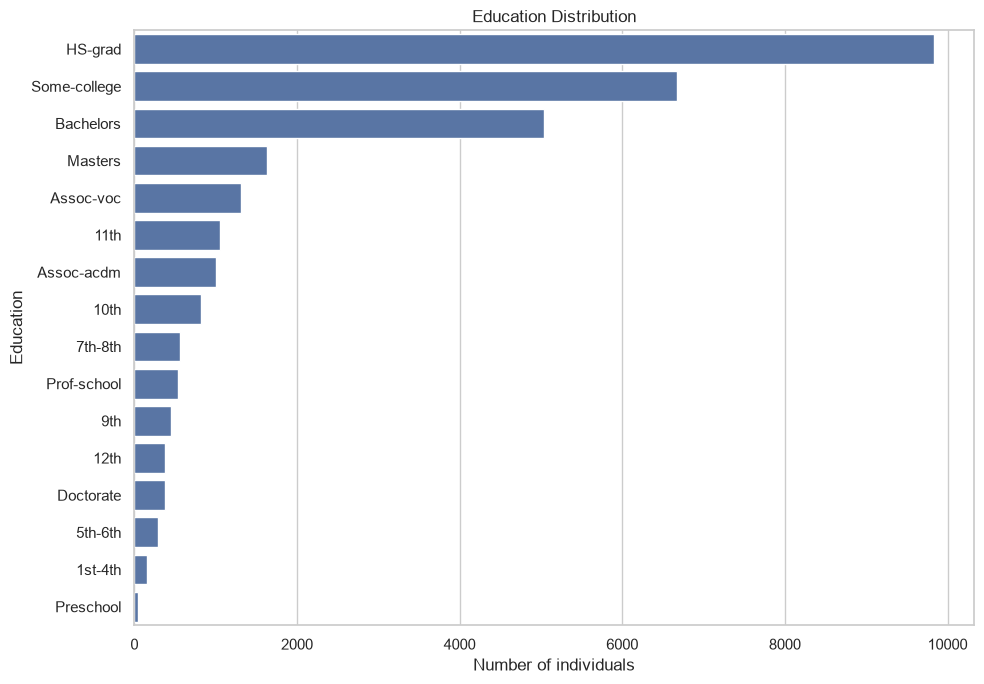

In [15]:
education_order = adult_clean["education"].value_counts().index
fig, ax = plt.subplots(figsize=(10, 7))
sns.countplot(data=adult_clean, y="education", order=education_order, ax=ax)
ax.set(title="Education Distribution", xlabel="Number of individuals", ylabel="Education")
plt.tight_layout()
plt.show()


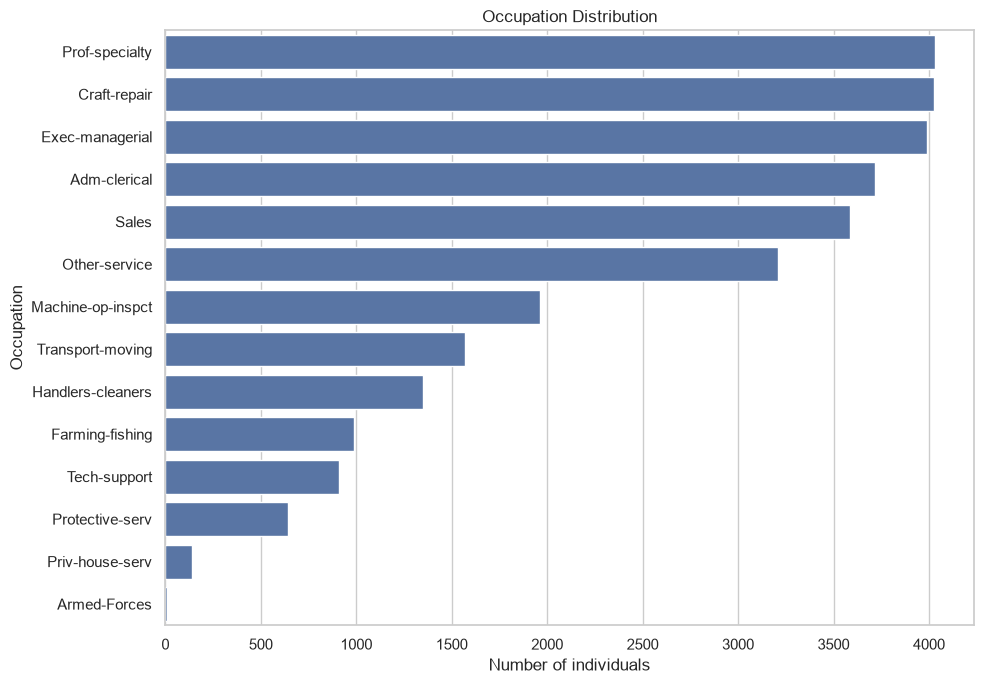

In [16]:
occupation_order = adult_clean["occupation"].value_counts().index
fig, ax = plt.subplots(figsize=(10, 7))
sns.countplot(data=adult_clean, y="occupation", order=occupation_order, ax=ax)
ax.set(title="Occupation Distribution", xlabel="Number of individuals", ylabel="Occupation")
plt.tight_layout()
plt.show()


## 7. Income-Focused Bivariate Analysis


In [17]:
# Helper: percentage earning >50K by a categorical feature.
def plot_high_income_rate(data, feature, title, min_count=1, top_n=None):
    summary = (
        data.groupby(feature, observed=False)["high_income"]
        .agg(high_income_rate="mean", sample_size="size")
        .query("sample_size >= @min_count")
        .assign(high_income_rate=lambda x: x["high_income_rate"] * 100)
        .sort_values("high_income_rate", ascending=False)
    )
    if top_n:
        summary = summary.head(top_n)

    fig, ax = plt.subplots(figsize=(10, max(4, len(summary) * 0.42)))
    sns.barplot(x=summary["high_income_rate"], y=summary.index, ax=ax)
    ax.set(title=title, xlabel="Percentage earning >50K", ylabel=feature.replace(".", " ").title())
    plt.tight_layout()
    plt.show()
    return summary


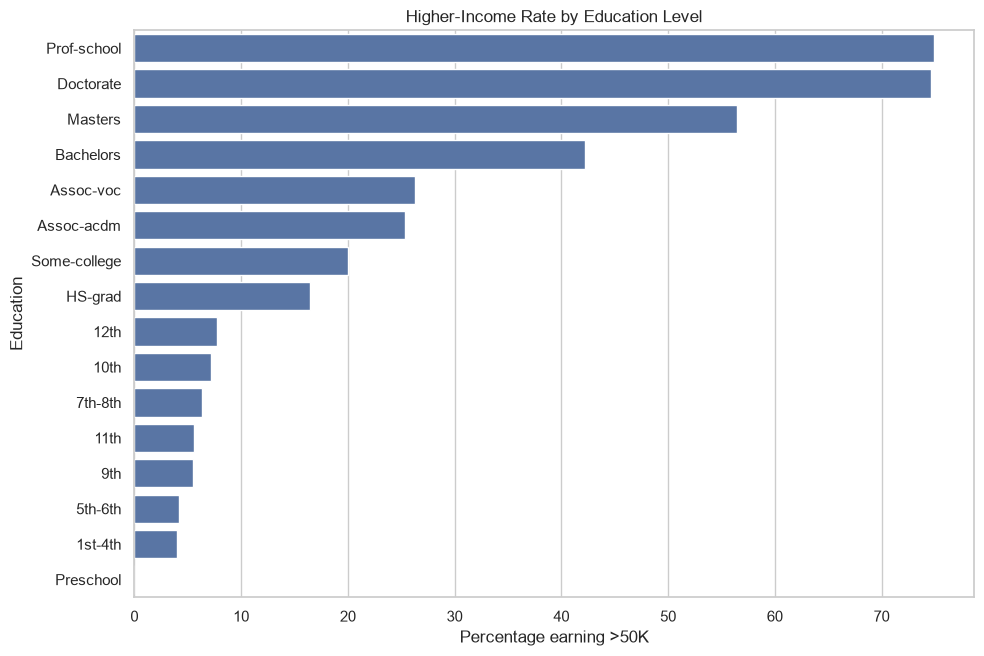

,high_income_rate,sample_size
education,,
Prof-school,74.907749,542
Doctorate,74.666667,375
Masters,56.457565,1626
Bachelors,42.165807,5042
Assoc-voc,26.319816,1307
Assoc-acdm,25.396825,1008
Some-college,20.017994,6669
HS-grad,16.432784,9834
12th,7.692308,377


In [18]:
education_income = plot_high_income_rate(
    adult_clean, "education",
    "Higher-Income Rate by Education Level"
)
education_income


### Education insight
The strongest education category in the cleaned data by observed `>50K` rate is **Prof-school**. More importantly, comparing **rates** rather than counts shows how likely individuals within each education category are to appear in the higher-income group, independent of category size.


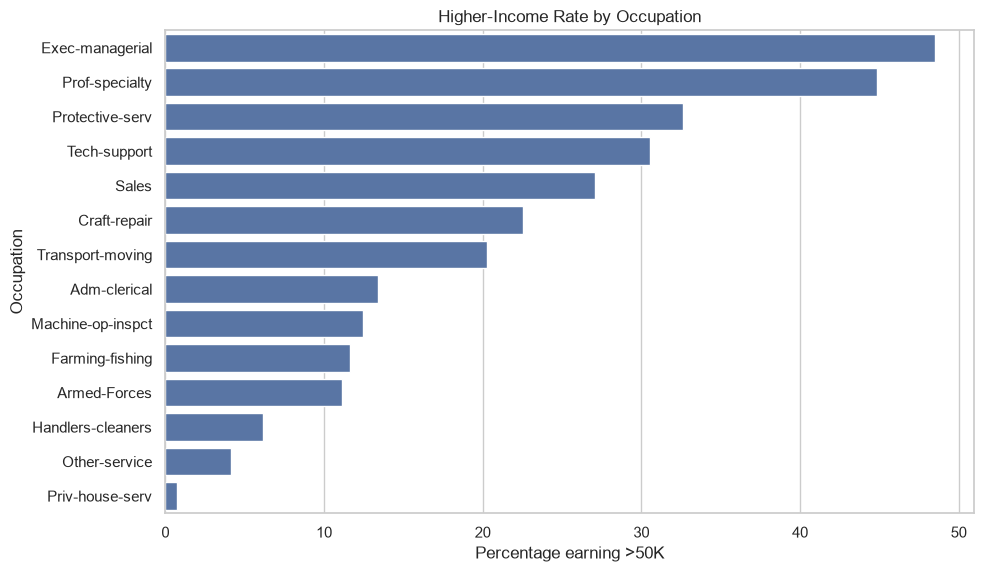

,high_income_rate,sample_size
occupation,,
Exec-managerial,48.534202,3991
Prof-specialty,44.868617,4034
Protective-serv,32.608696,644
Tech-support,30.515917,911
Sales,27.064732,3584
Craft-repair,22.559006,4025
Transport-moving,20.292621,1572
Adm-clerical,13.390696,3719
Machine-op-inspct,12.423625,1964


In [19]:
occupation_income = plot_high_income_rate(
    adult_clean, "occupation",
    "Higher-Income Rate by Occupation"
)
occupation_income


### Occupation insight
**Exec-managerial** has the highest observed higher-income rate among occupations in the cleaned dataset. The spread across occupations suggests occupation is an important feature to investigate alongside education, age and work hours.


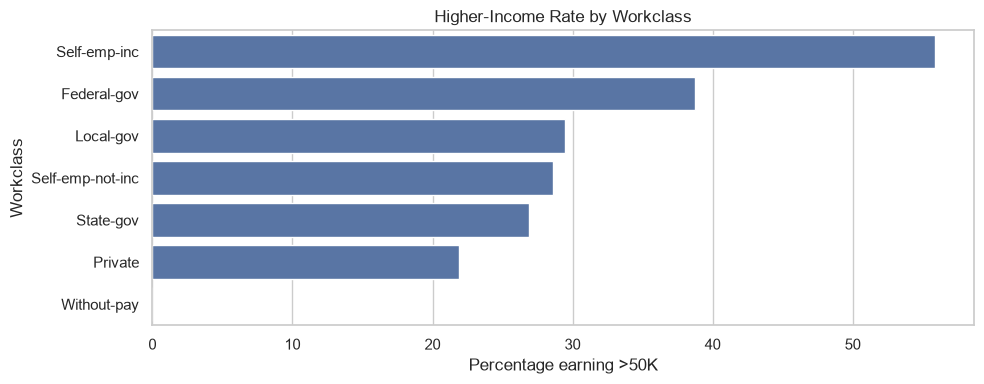

,high_income_rate,sample_size
workclass,,
Self-emp-inc,55.865922,1074
Federal-gov,38.706257,943
Local-gov,29.462990,2067
Self-emp-not-inc,28.582866,2498
State-gov,26.896013,1279
Private,21.891843,22264
Without-pay,0.000000,14


In [20]:
workclass_income = plot_high_income_rate(
    adult_clean, "workclass",
    "Higher-Income Rate by Workclass"
)
workclass_income


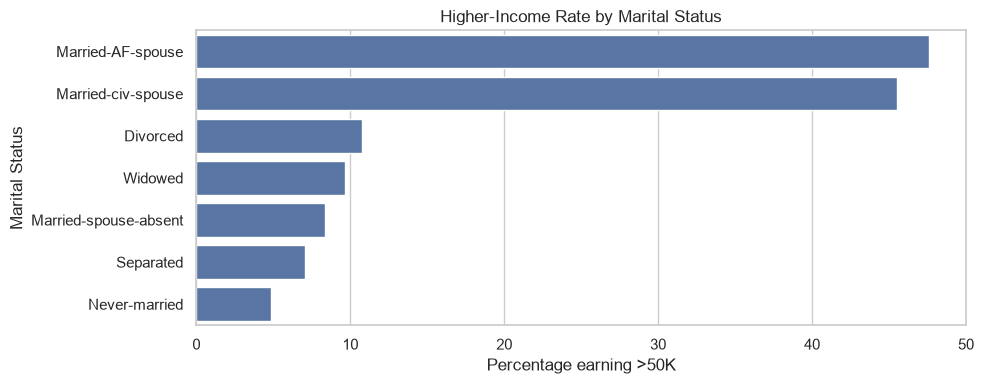

,high_income_rate,sample_size
marital.status,,
Married-AF-spouse,47.619048,21
Married-civ-spouse,45.501102,14059
Divorced,10.731244,4212
Widowed,9.673519,827
Married-spouse-absent,8.378378,370
Separated,7.028754,939
Never-married,4.839872,9711


In [21]:
marital_income = plot_high_income_rate(
    adult_clean, "marital.status",
    "Higher-Income Rate by Marital Status"
)
marital_income


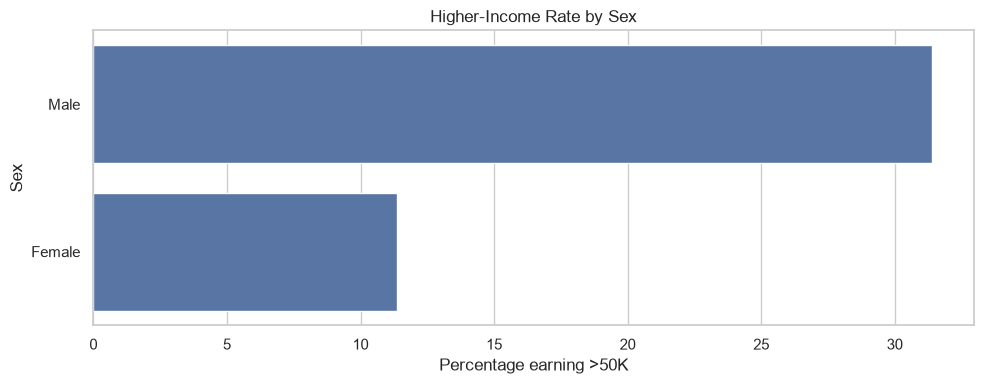

,high_income_rate,sample_size
sex,,
Male,31.395463,20366
Female,11.378287,9773


In [22]:
sex_income = plot_high_income_rate(
    adult_clean, "sex",
    "Higher-Income Rate by Sex"
)
sex_income


### Sex and income
The observed `>50K` rate differs between the sex categories in this dataset (Male: 31.4%, Female: 11.4%). This is a descriptive association, not evidence that sex itself causes the income difference; occupation, education, age, workclass and other factors may contribute to the observed gap.


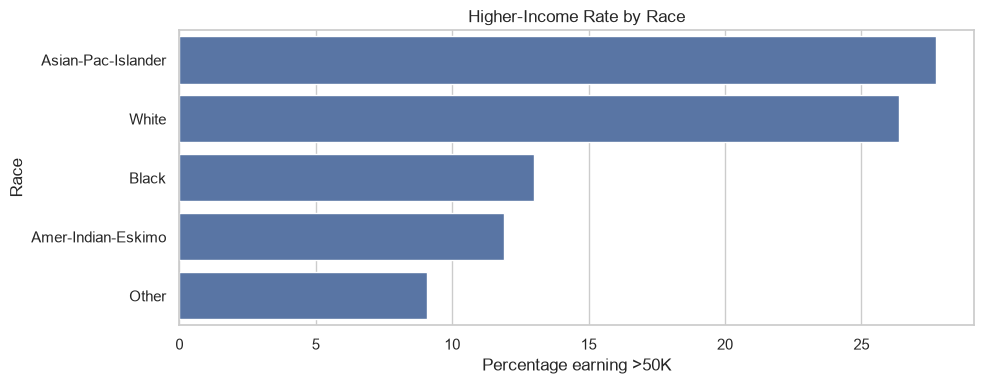

,high_income_rate,sample_size
race,,
Asian-Pac-Islander,27.740492,894
White,26.385458,25912
Black,12.997159,2816
Amer-Indian-Eskimo,11.888112,286
Other,9.090909,231


In [23]:
race_income = plot_high_income_rate(
    adult_clean, "race",
    "Higher-Income Rate by Race"
)
race_income


### Responsible interpretation
Differences across demographic groups should be treated carefully. These charts describe patterns in this historical dataset; they do not establish biological or causal explanations. Structural, occupational, educational and sampling factors may contribute to observed differences.


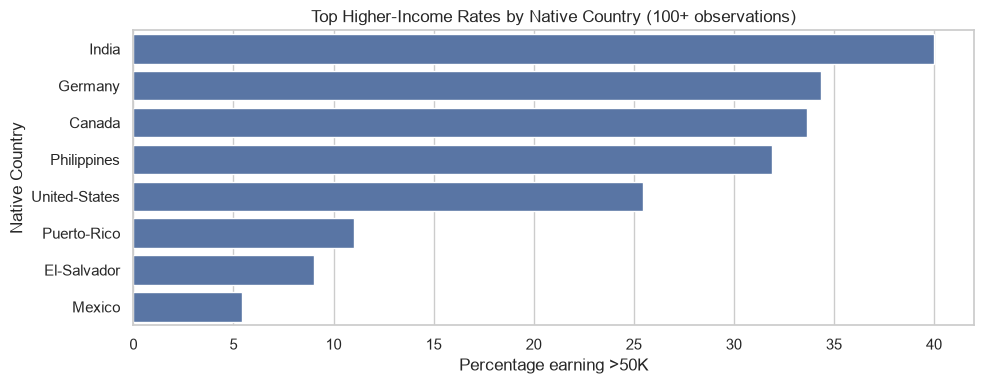

,high_income_rate,sample_size
native.country,,
India,40.000000,100
Germany,34.375000,128
Canada,33.644860,107
Philippines,31.914894,188
United-States,25.441118,27487
Puerto-Rico,11.009174,109
El-Salvador,9.000000,100
Mexico,5.445545,606


In [24]:
country_income = plot_high_income_rate(
    adult_clean, "native.country",
    "Top Higher-Income Rates by Native Country (100+ observations)",
    min_count=100,
    top_n=15
)
country_income


### Why filter small country groups?
A country represented by only a handful of observations can produce an extreme percentage by chance. Requiring a reasonable minimum sample size makes the ranking more stable and less misleading.


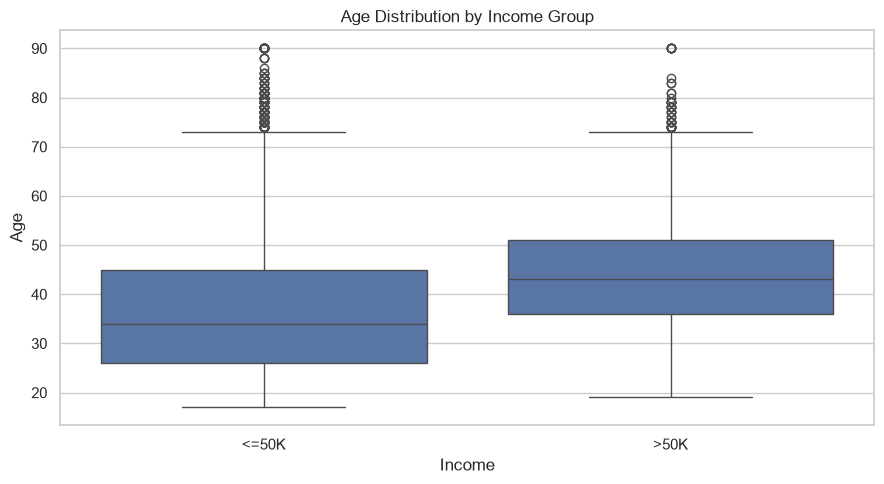

,mean,median,std,count
income,,,,
<=50K,36.61,34.0,13.46,22633
>50K,43.96,43.0,10.27,7506


In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=adult_clean, x="income", y="age", ax=ax)
ax.set(title="Age Distribution by Income Group", xlabel="Income", ylabel="Age")
plt.tight_layout()
plt.show()

adult_clean.groupby("income")["age"].agg(["mean", "median", "std", "count"]).round(2)


### Age insight
Average age is approximately **36.6 years** for the `<=50K` group and **44.0 years** for the `>50K` group. The boxplot adds context by showing overlap and spread rather than relying only on averages.


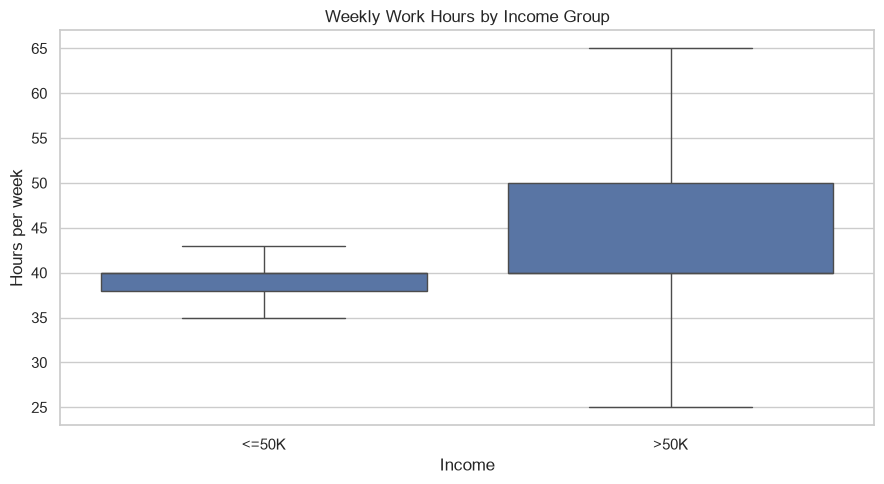

,mean,median,std,count
income,,,,
<=50K,39.35,40.0,11.95,22633
>50K,45.71,40.0,10.74,7506


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=adult_clean, x="income", y="hours.per.week", showfliers=False, ax=ax)
ax.set(title="Weekly Work Hours by Income Group", xlabel="Income", ylabel="Hours per week")
plt.tight_layout()
plt.show()

adult_clean.groupby("income")["hours.per.week"].agg(["mean", "median", "std", "count"]).round(2)


### Work-hours insight
The `>50K` group averages about **45.7 hours/week**, compared with **39.4 hours/week** for `<=50K`. The distributions still overlap substantially, so work hours alone do not determine income class.


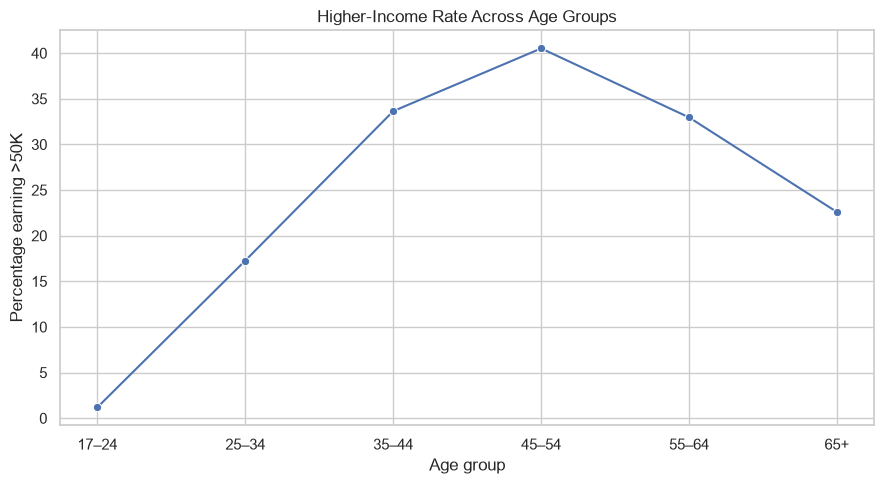

In [27]:
age_rate = adult_clean.groupby("age_group", observed=False)["high_income"].mean().mul(100)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(x=age_rate.index.astype(str), y=age_rate.values, marker="o", ax=ax)
ax.set(title="Higher-Income Rate Across Age Groups", xlabel="Age group", ylabel="Percentage earning >50K")
plt.tight_layout()
plt.show()


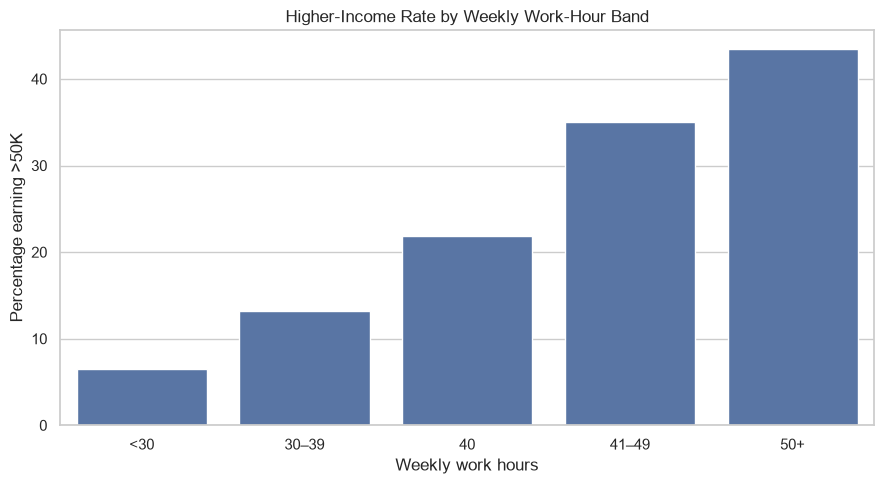

In [28]:
hours_rate = adult_clean.groupby("work_hours_group", observed=False)["high_income"].mean().mul(100)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=hours_rate.index.astype(str), y=hours_rate.values, ax=ax)
ax.set(title="Higher-Income Rate by Weekly Work-Hour Band", xlabel="Weekly work hours", ylabel="Percentage earning >50K")
plt.tight_layout()
plt.show()


## 8. Multivariate Exploration


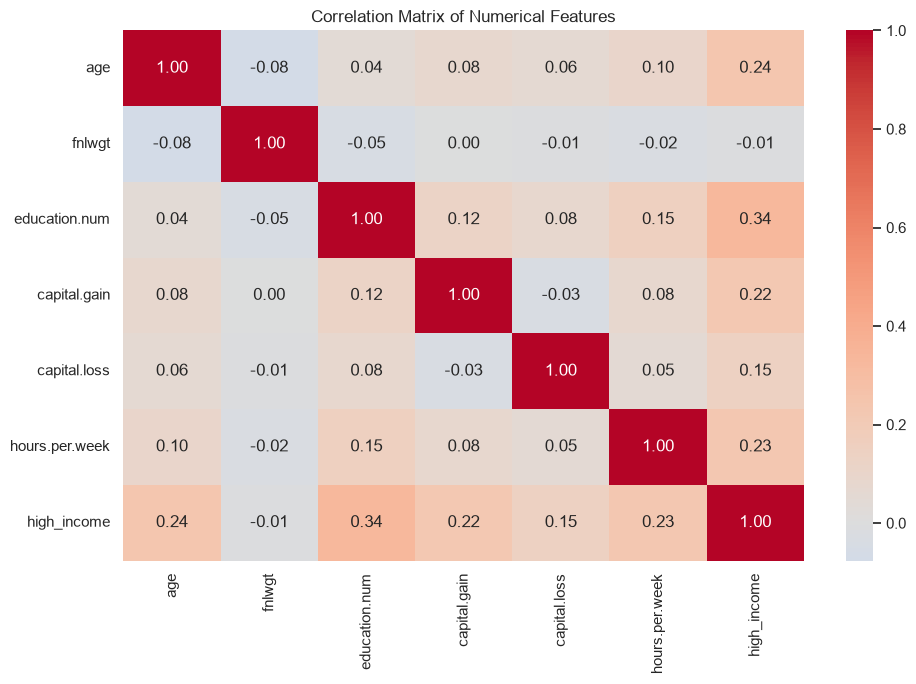

In [29]:
numeric_cols = [
    "age", "fnlwgt", "education.num",
    "capital.gain", "capital.loss",
    "hours.per.week", "high_income"
]

corr = adult_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


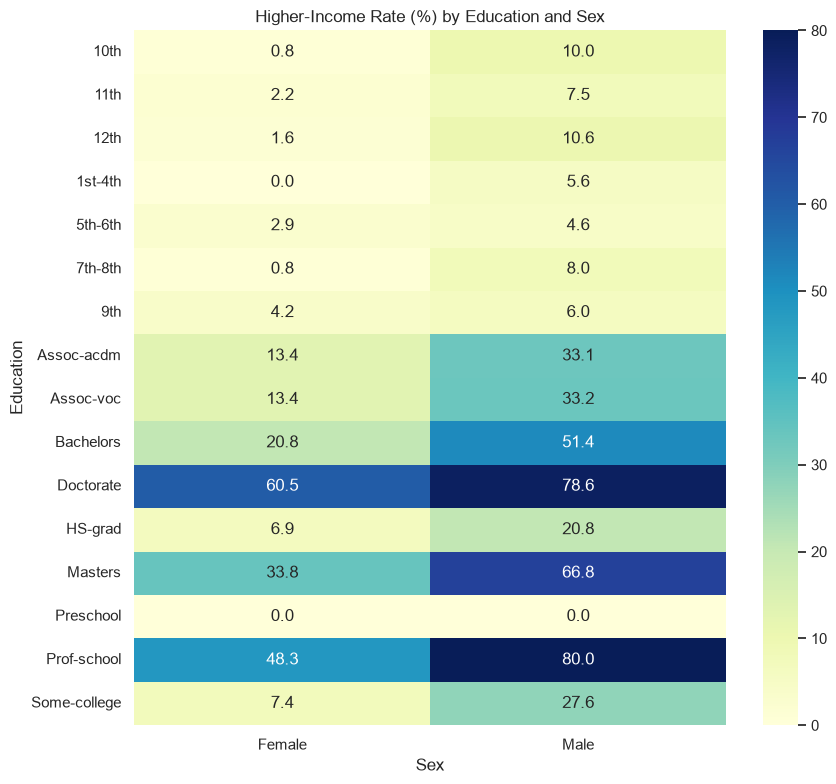

In [30]:
# Education x sex: high-income rate.
edu_sex = pd.pivot_table(
    adult_clean,
    values="high_income",
    index="education",
    columns="sex",
    aggfunc="mean"
) * 100

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(edu_sex, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax)
ax.set(title="Higher-Income Rate (%) by Education and Sex", xlabel="Sex", ylabel="Education")
plt.tight_layout()
plt.show()


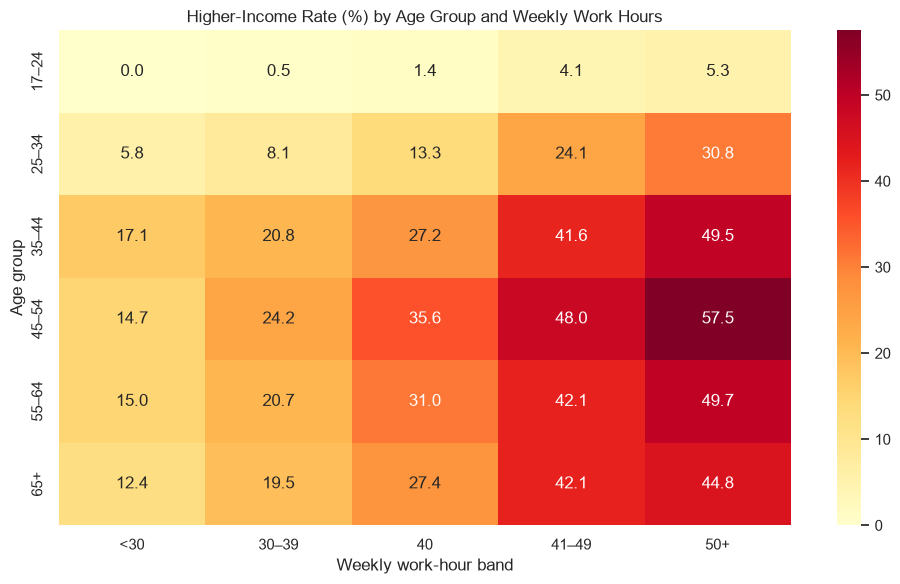

In [31]:
# Age group x weekly-hours band.
age_hours = pd.pivot_table(
    adult_clean,
    values="high_income",
    index="age_group",
    columns="work_hours_group",
    aggfunc="mean",
    observed=False
) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(age_hours, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set(title="Higher-Income Rate (%) by Age Group and Weekly Work Hours",
       xlabel="Weekly work-hour band", ylabel="Age group")
plt.tight_layout()
plt.show()


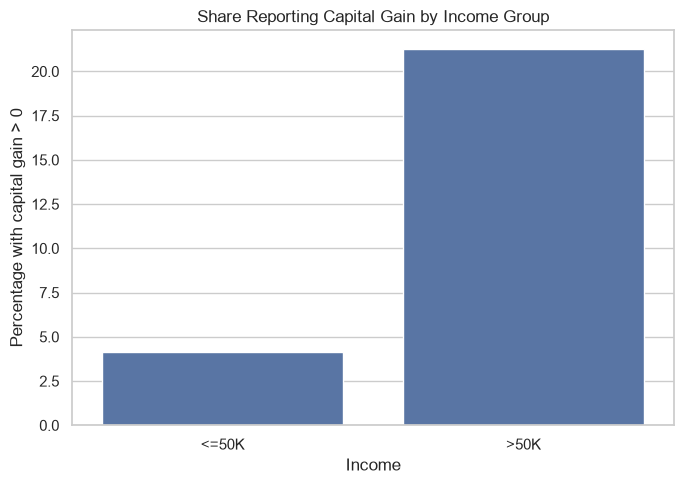

income
<=50K     4.17
>50K     21.25
Name: has_capital_gain, dtype: float64

In [32]:
# Capital gain is highly skewed, so compare prevalence of non-zero gain rather than only averages.
capital_summary = (
    adult_clean.assign(has_capital_gain=adult_clean["capital.gain"].gt(0))
    .groupby("income")["has_capital_gain"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=capital_summary.index, y=capital_summary.values, ax=ax)
ax.set(title="Share Reporting Capital Gain by Income Group",
       xlabel="Income", ylabel="Percentage with capital gain > 0")
plt.tight_layout()
plt.show()

capital_summary.round(2)


### Multivariate takeaway
The combined analyses show why a single-variable explanation is insufficient. Education, occupation, age, work hours and capital-related variables interact with the target in different ways. A predictive model would therefore benefit from considering several features simultaneously rather than relying on one characteristic.


## 9. Key Findings

1. **Income is imbalanced:** only about **24.9%** of the cleaned observations earn above $50K.
2. **Education matters descriptively:** higher-income rates vary substantially across education levels; **Prof-school** has the highest observed rate in this cleaned sample.
3. **Occupation separates income groups:** **Exec-managerial** records the highest observed `>50K` rate among occupations.
4. **Age differs across income groups:** the higher-income group is older on average in this dataset.
5. **Weekly hours show an association:** higher earners work more hours per week on average, although the distributions overlap.
6. **Demographic gaps exist in the data:** observed differences by sex and race should be interpreted as descriptive patterns, not causal conclusions.
7. **Category size matters:** percentages/rates provide a fairer comparison than raw counts when group sizes differ.
8. **Multiple variables matter together:** multivariate views reveal combinations of age, education and work intensity that cannot be seen from one-dimensional charts alone.


## 10. Recommendations and Next Steps

### Analytical recommendations
- Prefer **within-group percentages** when comparing income across categories.
- Report sample sizes alongside percentages for small groups.
- Avoid causal language when interpreting demographic differences.
- Consider robust treatment of highly skewed variables such as capital gain and capital loss.

### Next step: predictive modeling
This EDA can be extended into an income-classification project by:
1. Encoding categorical variables.
2. Creating a train/test split.
3. Establishing a baseline classifier.
4. Comparing models such as Logistic Regression, Decision Tree and Random Forest.
5. Evaluating with precision, recall, F1-score, ROC-AUC and a confusion matrix—not accuracy alone because the target is imbalanced.
6. Using feature importance or model explanations to compare predictive signals with the EDA findings.

### Final conclusion
The Adult Income dataset shows that higher-income status is associated with a combination of educational, occupational, demographic and work-related characteristics. The strongest analysis comes not from asking which group is largest, but from comparing **how income rates change within groups** and examining how multiple features behave together.
